# Кодирование категориальных переменных

Содержание:
1. Импорты библиотек
2. Описание данных
3. 
4. 
5. 


### 1. Импорты библиотек

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder


#### Настройки вывода

In [2]:
# Показать все колонки
pd.set_option('display.max_columns', None)
# Установить ширину отображения
pd.set_option('display.width', None)
# Отобразить все колонки без сокращения
pd.set_option('display.expand_frame_repr', False)

### 2. Описание данных

In [3]:
# Исходный датафрейм
df = pd.read_csv('imdb_top_1000.csv')

In [4]:
df.head(1)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"


Датасет с топ-1000 фильмов imdb

Параметры:
1) Poster_Link - ссылка на постер
2) Series_Title - название
3) Released_Year - год выхода
4) Certificate - возрастной рейтинг
5) Runtime - длительность
6) Genre - жанр
7) IMDB_Rating - рейтинг IMDB
8) Overview - описание
9) Meta_score - оценка Meta_score
10) Director - режиссер
11) Star1 - актер 1
12) Star2 - актер 2
13) Star3 - актер 3
14) Star4 - актер 4
15) No_of_Votes - число голосов
16) Gross - доход


In [5]:
df.info() ## получаем типы данных и число пропусков в колонках

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [6]:
## Оставим только первый жанр для простаты
df['Top_Genre'] = df['Genre'].str.split(',').str[0]
## Убираем числовые показатели кроме IMDB_Rating и убираю лишние показатели ссылки и подробное текстовое описание
df = df.drop(['Poster_Link','Meta_score','No_of_Votes','Released_Year','Runtime','Gross','Overview','Genre'], axis=1)
df

,Series_Title,Certificate,IMDB_Rating,Director,Star1,Star2,Star3,Star4,Top_Genre
0,The Shawshank Redemption,A,9.3,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,Drama
1,The Godfather,A,9.2,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,Crime
2,The Dark Knight,UA,9.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,Action
3,The Godfather: Part II,A,9.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,Crime
4,12 Angry Men,U,9.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,Crime
...,...,...,...,...,...,...,...,...,...
995,Breakfast at Tiffany's,A,7.6,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,Comedy
996,Giant,G,7.6,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,Drama
997,From Here to Eternity,Passed,7.6,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,Drama
998,Lifeboat,NaN,7.6,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,Drama


In [7]:
## Посмотрим сколько какие уникальные значения есть в данном столбце и сколько их
print(df.Top_Genre.unique())
print(df.Top_Genre.value_counts().count())
## Выводим частоту
df.Top_Genre.value_counts()

['Drama' 'Crime' 'Action' 'Biography' 'Western' 'Comedy' 'Adventure'
 'Animation' 'Horror' 'Mystery' 'Film-Noir' 'Fantasy' 'Family' 'Thriller']
14


Top_Genre
Drama        289
Action       172
Comedy       155
Crime        107
Biography     88
Animation     82
Adventure     72
Mystery       12
Horror        11
Western        4
Film-Noir      3
Fantasy        2
Family         2
Thriller       1
Name: count, dtype: int64

Text(0.5, 0, 'Категории')

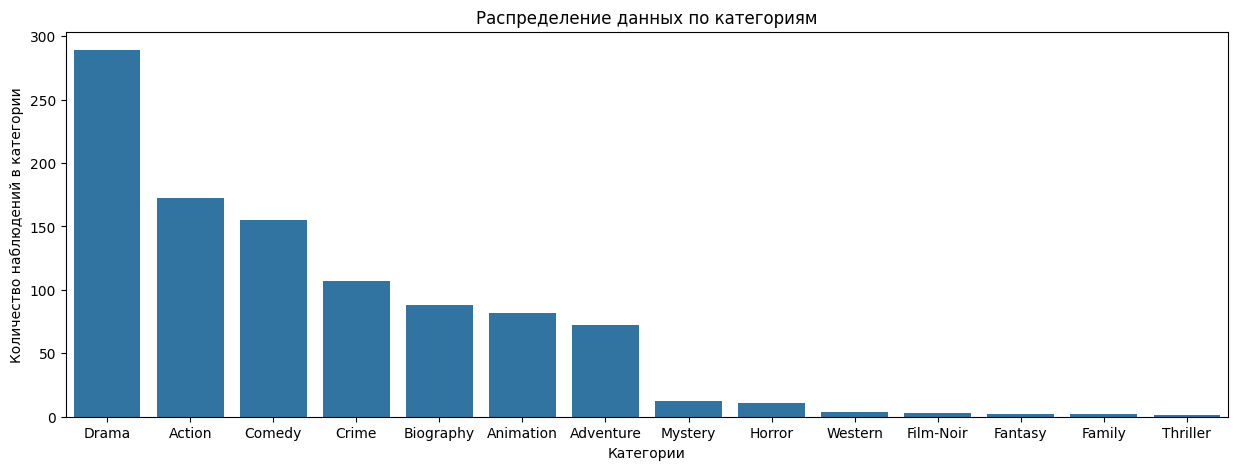

In [8]:
## Можем посмотреть на это визуально
matplotlib.rcParams['figure.figsize'] = (15, 5)
Top_Genre = df.Top_Genre.value_counts()
sns.barplot(x = Top_Genre.index, y = Top_Genre.values)
plt.title('Распределение данных по категориям')
plt.ylabel('Количество наблюдений в категории')
plt.xlabel('Категории')

### Тип данных категория

In [9]:
## Проставляем категорию в тип данных
df = df.astype({'Certificate' : 'category', 'Top_Genre' : 'category'})

In [10]:
## Просто проставляем коды
df.Certificate_code = df.Certificate.astype('category').cat.codes

C:\Users\n3sm3\AppData\Local\Temp\ipykernel_6020\2602829696.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.Certificate_code = df.Certificate.astype('category').cat.codes


In [11]:
df.Top_Genre.value_counts()

Top_Genre
Drama        289
Action       172
Comedy       155
Crime        107
Biography     88
Animation     82
Adventure     72
Mystery       12
Horror        11
Western        4
Film-Noir      3
Family         2
Fantasy        2
Thriller       1
Name: count, dtype: int64

In [12]:
### Или делаем мапинг
map_dict = {'Drama' : 0,
            'Crime' : 1,
            'Action': 2,
            'Comedy': 3,
            'Biography': 4,
            'Western': 5,
            'Mystery': 6,
            'Noir': 7,
            'Fantasy': 8,
            'Family': 9,
            'Thriller': 10,
            'Animation': 11,
            'Adventure': 12,
            'Horror': 13 }
 
df['Top_Genre'] = df['Top_Genre'].map(map_dict)


In [13]:
df

,Series_Title,Certificate,IMDB_Rating,Director,Star1,Star2,Star3,Star4,Top_Genre
0,The Shawshank Redemption,A,9.3,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,0.0
1,The Godfather,A,9.2,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1.0
2,The Dark Knight,UA,9.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2.0
3,The Godfather: Part II,A,9.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1.0
4,12 Angry Men,U,9.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,1.0
...,...,...,...,...,...,...,...,...,...
995,Breakfast at Tiffany's,A,7.6,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,3.0
996,Giant,G,7.6,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,0.0
997,From Here to Eternity,Passed,7.6,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,0.0
998,Lifeboat,NaN,7.6,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,0.0


In [14]:
## Библиотечный энкодер
labelencoder = LabelEncoder()
df.loc[:, 'Star1'] = labelencoder.fit_transform(df.loc[:, 'Star1'])

In [15]:
labelencoder.classes_

array(['Aamir Khan', 'Aaron Taylor-Johnson', 'Abhay Deol',
       'Abraham Attah', 'Adam Driver', 'Adrian Molina', 'Adrien Brody',
       'Ajay Devgn', 'Akshay Kumar', 'Al Pacino', 'Alain Delon',
       'Alan Mak', 'Alec Guinness', 'Alejandro Jodorowsky',
       'Aleksandr Antonov', 'Aleksey Kravchenko', 'Aleksey Serebryakov',
       'Alia Bhatt', 'Alicia Vikander', 'Alisa Freyndlikh', 'Amit Sadh',
       'Amitabh Bachchan', 'Amole Gupte', 'Amy Adams', 'Amy Poehler',
       'Anamaria Marinca', 'Anand Gandhi', 'Anatoliy Solonitsyn',
       'Andie MacDowell', 'Andreas Wilson', 'Andrew Garfield',
       'Andrew Marton', 'Andrew Philpot', 'Angelina Jolie', 'Anna Karina',
       'Anne Dorval', 'Ansel Elgort', 'Anthony Hopkins',
       'Anthony Perkins', 'Anthony Quinn', 'Antonio Banderas',
       'Anupam Kher', 'Aoi Miyazaki', 'Aras Bulut Iynemli',
       'Armie Hammer', 'Arnold Schwarzenegger', 'Arthur Rosson',
       'Asa Butterfield', 'Ash Brannon', 'Atsuko Tanaka',
       'Audrey Hepbur

In [25]:
ordinalencoder = OrdinalEncoder(categories = ['A', 'UA', 'U', 'PG-13', 'R', 'Passed', 'Unrated', 'GP', 'Approved', 'TV-PG', 'U/A'])

In [31]:
df['Certificate'].unique()[:8]

['A', 'UA', 'U', 'PG-13', 'R', NaN, 'PG', 'G']
Categories (16, object): ['16', 'A', 'Approved', 'G', ..., 'U', 'U/A', 'UA', 'Unrated']

In [26]:
df['Certificate_oe'] = df['Certificate'].astype('object')
df.loc[:, 'Certificate_oe'] = ordinalencoder.fit_transform(df.loc[:, 'Certificate_oe'].to_frame())
df

ValueError: Shape mismatch: if categories is an array, it has to be of shape (n_features,).